In [ ]:
## step 1 :-choose k value
## step 2:-find k nearest neighbors
## step 3 :-step-3: majority of class
## step 4 :-assign predicted class to majority class


## knn depends on distance matrix mainly euclidean distance

In [9]:
## LOAD IRIS DATASET
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
display(df.tail(-70))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
70,5.9,3.2,4.8,1.8,1
71,6.1,2.8,4.0,1.3,1
72,6.3,2.5,4.9,1.5,1
73,6.1,2.8,4.7,1.2,1
74,6.4,2.9,4.3,1.3,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [10]:
## data preprocessing
from sklearn.model_selection import train_test_split
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y,   test_size=0.2, random_state=42)

In [14]:
## hyperparameter tuning for knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
best_k = 5
best_score = 0
for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    score = accuracy_score(y_test, pred)
    if score > best_score:
        best_score = score
        best_k = k

print(f"Best k: {best_k}, Best accuracy: {best_score}")

Best k: 1, Best accuracy: 1.0


In [15]:
## accuraccy, precision, recall, f1-score
from sklearn.metrics import classification_report
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print(classification_report(y_test, pred)) 


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


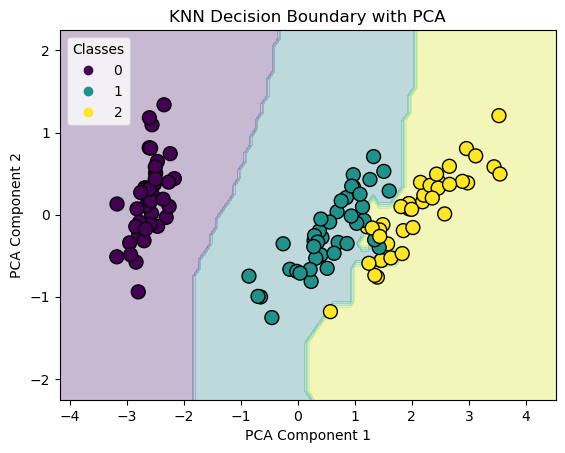

In [16]:
## decision boundary visualization
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA  
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = knn.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', s=100)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KNN Decision Boundary with PCA')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.show()

In [17]:
## test accuracy_score and train accuracy_score
train_pred = knn.predict(X_train)
train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, pred)
print(f"Train Accuracy: {train_score}, Test Accuracy: {test_score}")

Train Accuracy: 1.0, Test Accuracy: 1.0
